# 📚 Système de Recommandation — Bibliothèque Numérique UAC

**Université de l'Assomption au Congo (UAC) — Butembo, Nord-Kivu, RDC**

Ce notebook implémente un système de recommandation **content-based** (filtrage par contenu)
basé sur la vectorisation TF-IDF et la similarité cosinus.

### Pipeline
```
data/uac_bibliotheque.csv
        ↓
Prétraitement & nettoyage
        ↓
Vectorisation TF-IDF (titre + auteur + domaine + description)
        ↓
Matrice de similarité cosinus
        ↓
Fonction de recommandation
        ↓
Sauvegarde des artifacts (pickle)
```

### Pourquoi content-based ?
La bibliothèque UAC ne dispose pas de données de ratings utilisateurs.
Le filtrage par contenu permet de recommander des ouvrages similaires
uniquement à partir des métadonnées (titre, auteur, domaine, description).

## 1. Installation & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import yaml
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

print('✅ Imports OK')

✅ Imports OK


## 2. Chargement des données

> Assure-toi d'avoir exécuté `uac_scraper.ipynb` au préalable pour générer `data/uac_bibliotheque.csv`.

In [2]:
CSV_PATH = 'data/uac_bibliotheque.csv'

df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')

print(f'✅ Dataset chargé : {df.shape[0]} ouvrages | {df.shape[1]} colonnes')
print(f'Colonnes : {list(df.columns)}')
df.head()

✅ Dataset chargé : 2946 ouvrages | 7 colonnes
Colonnes : ['titre', 'auteur', 'isbn', 'domaine', 'description', 'image_url', 'url_detail']


,titre,auteur,isbn,domaine,description,image_url,url_detail
0,Software Requirements,"Karl Wiegers, Joey Beatty",978-0-7356-7966-5,Sciences Informatiques,NaN,NaN,https://bibliothequenumerique.uaconline.edu.cd...
1,"Database Systems Design, Implementation, and M...","Carlos Coronel, Steven Morris, Peter Rob",978-1-111-96960-8,Sciences Informatiques,NaN,NaN,https://bibliothequenumerique.uaconline.edu.cd...
2,Operating Systems Three Easy Pieces,"Remzi H. Arpaci-Dusseau, Andrea C Arpaci-Dusseau",9781985086593,Sciences Informatiques,NaN,NaN,https://bibliothequenumerique.uaconline.edu.cd...
3,Gérer un parc informatique une initiation pra...,Le Bel Pierre,2-922889-08-4,Sciences Informatiques,NaN,NaN,https://bibliothequenumerique.uaconline.edu.cd...
4,Systèmes d’information géographique,Yves Auda,978-2-10-084196-7,Sciences Informatiques,NaN,NaN,https://bibliothequenumerique.uaconline.edu.cd...


## 3. Analyse Exploratoire (EDA)

In [3]:
print('=== STATISTIQUES GÉNÉRALES ===')
print(f'Total ouvrages         : {len(df)}')
print(f'Domaines uniques       : {df["domaine"].nunique()}')
print(f'Auteurs uniques        : {df["auteur"].nunique()}')
print(f'Ouvrages sans auteur   : {(df["auteur"] == "").sum()}')
print(f'Ouvrages sans desc.    : {(df["description"] == "").sum()}')
print()
df.info()

=== STATISTIQUES GÉNÉRALES ===
Total ouvrages         : 2946
Domaines uniques       : 38
Auteurs uniques        : 2672
Ouvrages sans auteur   : 0
Ouvrages sans desc.    : 0

<class 'pandas.DataFrame'>
RangeIndex: 2946 entries, 0 to 2945
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   titre        2946 non-null   str    
 1   auteur       2946 non-null   str    
 2   isbn         2442 non-null   str    
 3   domaine      2946 non-null   str    
 4   description  0 non-null      float64
 5   image_url    0 non-null      float64
 6   url_detail   2946 non-null   str    
dtypes: float64(2), str(5)
memory usage: 714.0 KB


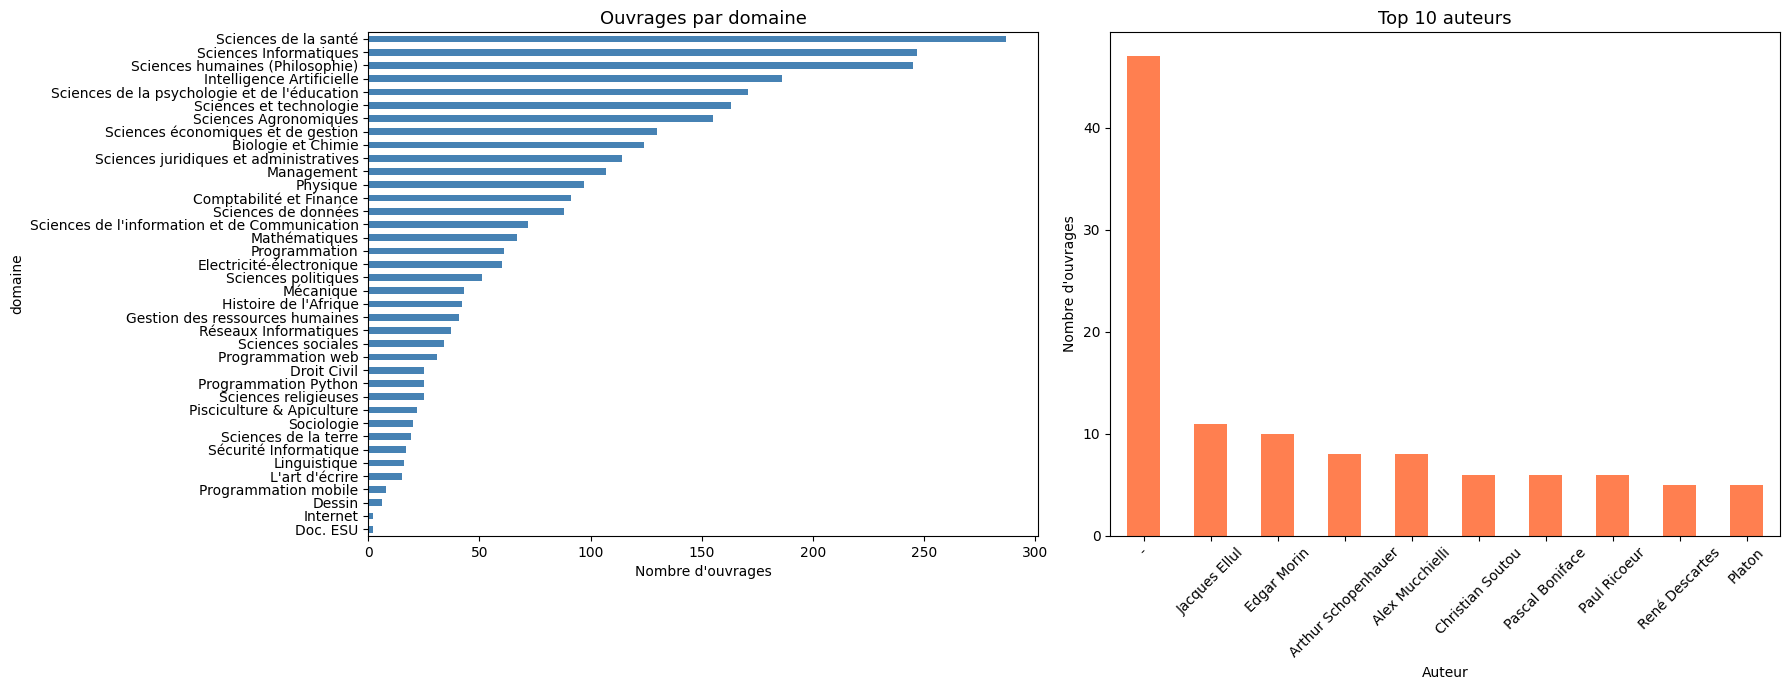

In [4]:
# Répartition par domaine
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Barplot horizontal
repartition = df['domaine'].value_counts()
repartition.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Ouvrages par domaine', fontsize=13)
axes[0].set_xlabel('Nombre d\'ouvrages')
axes[0].invert_yaxis()

# Top 10 auteurs
top_auteurs = df[df['auteur'] != '']['auteur'].value_counts().head(10)
top_auteurs.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 10 auteurs', fontsize=13)
axes[1].set_xlabel('Auteur')
axes[1].set_ylabel('Nombre d\'ouvrages')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data/eda_uac.png', dpi=150)
plt.show()

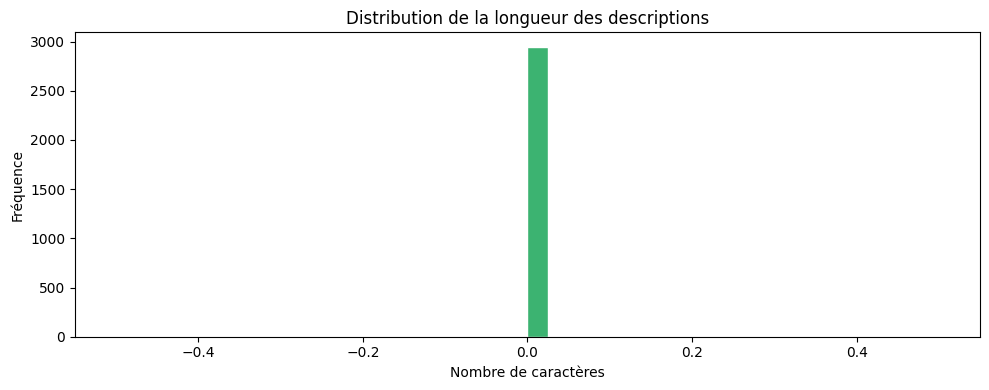

Longueur moyenne : 0 caractères
Ouvrages sans description : 2946


In [5]:
# Distribution de la longueur des descriptions
df['desc_len'] = df['description'].fillna('').apply(len)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['desc_len'], bins=40, color='mediumseagreen', edgecolor='white')
ax.set_title('Distribution de la longueur des descriptions')
ax.set_xlabel('Nombre de caractères')
ax.set_ylabel('Fréquence')
plt.tight_layout()
plt.show()

print(f'Longueur moyenne : {df["desc_len"].mean():.0f} caractères')
print(f'Ouvrages sans description : {(df["desc_len"] == 0).sum()}')

## 4. Prétraitement des données

In [6]:
def nettoyer_texte(texte) -> str:
    """Normalise un champ texte : minuscules, suppression espaces superflus."""
    if pd.isna(texte) or str(texte).strip() == '':
        return ''
    return str(texte).lower().strip()


# Colonnes obligatoires — toujours présentes
df['titre']       = df['titre'].apply(nettoyer_texte)
df['auteur']      = df['auteur'].apply(nettoyer_texte)
df['domaine']     = df['domaine'].apply(nettoyer_texte)
df['description'] = df['description'].apply(nettoyer_texte)

# FIX : colonnes optionnelles — présentes seulement si l'enrichissement
# du scraper a été exécuté (etape 7 du scraper). On les crée si absentes.
for col in ['categorie', 'edition', 'annee']:
    if col not in df.columns:
        df[col] = ''
        print(f'⚠️  Colonne "{col}" absente → créée vide (enrichissement scraper non exécuté)')
    else:
        df[col] = df[col].fillna('').apply(nettoyer_texte)

# Supprimer les ouvrages sans titre
avant = len(df)
df = df[df['titre'] != ''].reset_index(drop=True)
print(f'Ouvrages sans titre supprimés : {avant - len(df)}')

# Colonne combinée pour TF-IDF
# Pondération : titre x3 (plus important), auteur x2, domaine x2, description x1
# categorie ajoutée seulement si disponible
df['contenu'] = (
    df['titre']       + ' ' + df['titre']       + ' ' + df['titre']   + ' ' +
    df['auteur']      + ' ' + df['auteur']      + ' ' +
    df['domaine']     + ' ' + df['domaine']     + ' ' +
    df['description'] + ' ' +
    df['categorie']
).str.strip()

print(f'✅ Prétraitement terminé — {len(df)} ouvrages prêts')
print(f'   Colonnes disponibles : {list(df.columns)}')
df[['titre', 'auteur', 'domaine', 'contenu']].head(3)

⚠️  Colonne "categorie" absente → créée vide (enrichissement scraper non exécuté)
⚠️  Colonne "edition" absente → créée vide (enrichissement scraper non exécuté)
⚠️  Colonne "annee" absente → créée vide (enrichissement scraper non exécuté)
Ouvrages sans titre supprimés : 0
✅ Prétraitement terminé — 2946 ouvrages prêts
   Colonnes disponibles : ['titre', 'auteur', 'isbn', 'domaine', 'description', 'image_url', 'url_detail', 'desc_len', 'categorie', 'edition', 'annee', 'contenu']


,titre,auteur,domaine,contenu
0,software requirements,"karl wiegers, joey beatty",sciences informatiques,software requirements software requirements so...
1,"database systems design, implementation, and m...","carlos coronel, steven morris, peter rob",sciences informatiques,"database systems design, implementation, and m..."
2,operating systems three easy pieces,"remzi h. arpaci-dusseau, andrea c arpaci-dusseau",sciences informatiques,operating systems three easy pieces operating ...


## 5. Vectorisation TF-IDF

TF-IDF (*Term Frequency — Inverse Document Frequency*) mesure l'importance
de chaque mot dans un ouvrage **par rapport à l'ensemble de la collection**.
Les mots fréquents dans tous les ouvrages (ex. "les", "de") sont automatiquement
déprioritisés.

In [7]:
tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),      # unigrammes + bigrammes
    min_df=1,                # garder tous les termes (petit corpus)
    stop_words=None,         # pas de stop words : corpus multilingue FR/EN
    max_features=10000       # limite pour la performance
)

tfidf_matrix = tfidf.fit_transform(df['contenu'])

print(f'✅ Matrice TF-IDF : {tfidf_matrix.shape}')
print(f'   {tfidf_matrix.shape[0]} ouvrages × {tfidf_matrix.shape[1]} termes')
print(f'   Densité : {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4f}')

✅ Matrice TF-IDF : (2946, 10000)
   2946 ouvrages × 10000 termes
   Densité : 0.0018


## 6. Matrice de similarité cosinus

In [8]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f'✅ Matrice de similarité : {cosine_sim.shape}')
print(f'   Min : {cosine_sim.min():.4f} | Max (hors diagonale) : {np.sort(cosine_sim, axis=1)[:, -2].max():.4f}')
print(f'   Mémoire estimée : {cosine_sim.nbytes / 1e6:.1f} MB')

✅ Matrice de similarité : (2946, 2946)
   Min : 0.0000 | Max (hors diagonale) : 1.0000
   Mémoire estimée : 69.4 MB


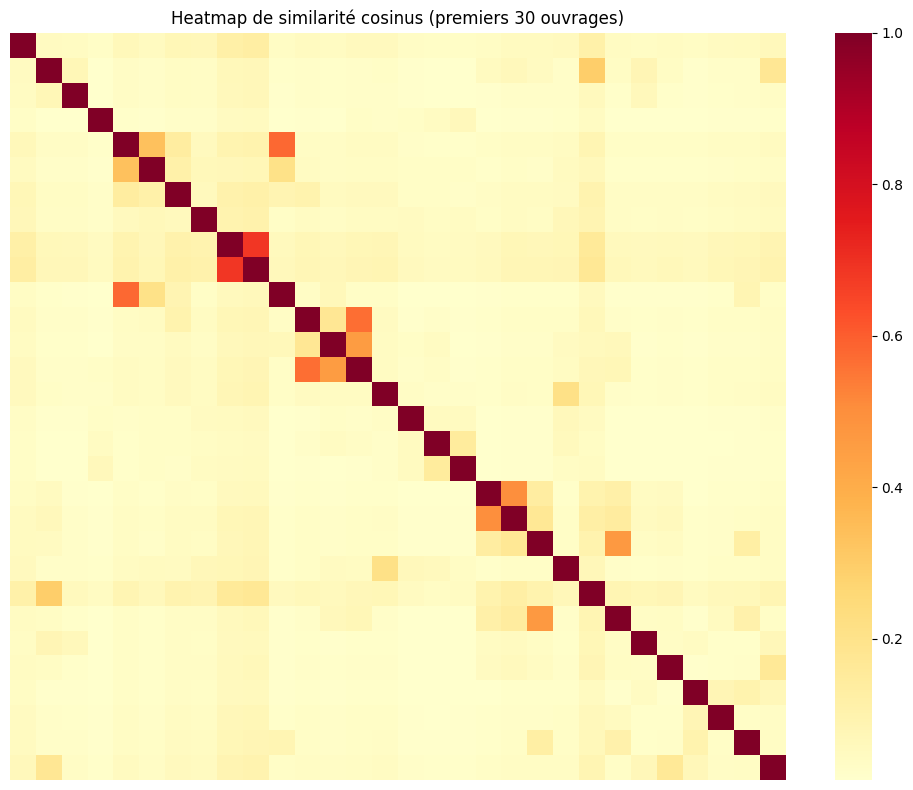

In [9]:
# Visualisation : heatmap d'un sous-ensemble
N = min(30, len(df))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cosine_sim[:N, :N],
    cmap='YlOrRd',
    ax=ax,
    xticklabels=False,
    yticklabels=False
)
ax.set_title(f'Heatmap de similarité cosinus (premiers {N} ouvrages)')
plt.tight_layout()
plt.show()

## 7. Fonction de recommandation

In [10]:
def recommander_ouvrage(titre: str, n: int = 5,
                        filtre_domaine: str = None) -> pd.DataFrame:
    """
    Recommande les n ouvrages les plus similaires à `titre`.

    Paramètres
    ----------
    titre          : titre exact de l'ouvrage (tel qu'il apparaît dans df['titre'])
    n              : nombre de recommandations (défaut : 5)
    filtre_domaine : si précisé, limite les recommandations à ce domaine

    Retourne
    --------
    DataFrame avec colonnes : rang, titre, auteur, domaine, score_similarite, image_url
    """
    titre = titre.lower().strip()
    indices = df[df['titre'] == titre].index

    if len(indices) == 0:
        print(f'❌ Ouvrage introuvable : "{titre}"')
        print('💡 Essaie get_suggestions() pour trouver le titre exact.')
        return pd.DataFrame()

    idx = indices[0]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    resultats = []
    rang = 1
    for i, score in scores:
        if i == idx:
            continue  # ignorer l'ouvrage lui-même
        row = df.iloc[i]
        if filtre_domaine and row['domaine'] != filtre_domaine.lower():
            continue
        resultats.append({
            'rang':              rang,
            'titre':             row['titre'],
            'auteur':            row['auteur'],
            'domaine':           row['domaine'],
            'score_similarite':  round(score, 4),
            'image_url':         row.get('image_url', ''),
            'url_detail':        row.get('url_detail', ''),
        })
        rang += 1
        if rang > n:
            break

    return pd.DataFrame(resultats)


def get_suggestions(query: str, n: int = 5) -> list:
    """
    Recherche partielle : retourne les titres contenant `query`.
    Utile pour trouver le titre exact avant d'appeler recommander_ouvrage().
    """
    query = query.lower().strip()
    matches = df[df['titre'].str.contains(query, na=False)]['titre'].tolist()
    return matches[:n]


print('✅ Fonctions de recommandation définies')

✅ Fonctions de recommandation définies


## 8. Tests de recommandation

In [11]:
# --- Test 1 : recherche partielle pour trouver un titre ---
print('🔎 Suggestions pour "python" :')
print(get_suggestions('python', n=8))

🔎 Suggestions pour "python" :
['informatique pour tous - programmation python, langage sql - cpge scientifiques (1re et 2e années) - fiches-méthodes et...', 'deep learning for computer vision - image classification, object detection and face recognition in python', 'data mining  for business analytics. concepts, techniques, and applications in python', 'a prendre à programmer avec python', 'learning algorithms for internet of things: applying python tools to improve data collection use for system performance', 'internet of things programming projects: build exciting iot projects using raspberry pi 5, raspberry pi pico, and python', 'deep learning for computer vision with python', 'web scraping with python,']


In [12]:
# --- Test 2 : recommandation générale ---
# Remplace le titre ci-dessous par un titre trouvé dans get_suggestions()
TITRE_TEST = get_suggestions('python', n=1)[0] if get_suggestions('python') else df['titre'].iloc[0]

print(f'📖 Recommandations pour : "{TITRE_TEST}"\n')
resultats = recommander_ouvrage(TITRE_TEST, n=5)
print(resultats[['rang', 'titre', 'auteur', 'domaine', 'score_similarite']].to_string(index=False))

📖 Recommandations pour : "informatique pour tous - programmation python, langage sql - cpge scientifiques (1re et 2e années) - fiches-méthodes et..."

 rang                                            titre             auteur                domaine  score_similarite
    1                     programmation python avancée       xavier olive   programmation python            0.2218
    2                             programmation python        tarek ziadé   programmation python            0.2150
    3                            algorithmie en python développeur python   programmation python            0.1934
    4             lexique informatique  pour debutants     jean boulanger sciences informatiques            0.1895
    5 programmation python. conception et optimisation        tarek ziadé   programmation python            0.1701


In [13]:
# --- Test 3 : recommandation filtrée par domaine ---
TITRE_TEST2 = df['titre'].iloc[0]
DOMAINE_FILTRE = df['domaine'].iloc[0]

print(f'📖 Recommandations pour "{TITRE_TEST2}" dans le domaine "{DOMAINE_FILTRE}"\n')
resultats_filtres = recommander_ouvrage(TITRE_TEST2, n=5, filtre_domaine=DOMAINE_FILTRE)
print(resultats_filtres[['rang', 'titre', 'auteur', 'score_similarite']].to_string(index=False))

📖 Recommandations pour "software requirements" dans le domaine "sciences informatiques"

 rang                                    titre                    auteur  score_similarite
    1     software architecture for developers               simon brown            0.3249
    2           software engineering  with uml           bhuvan unhelkar            0.2863
    3        software development  from a to z olga filipova & rui vilão            0.2809
    4 software development,  design and coding            john f. dooley            0.2220
    5                les crises du capitalisme                 karl marx            0.1565


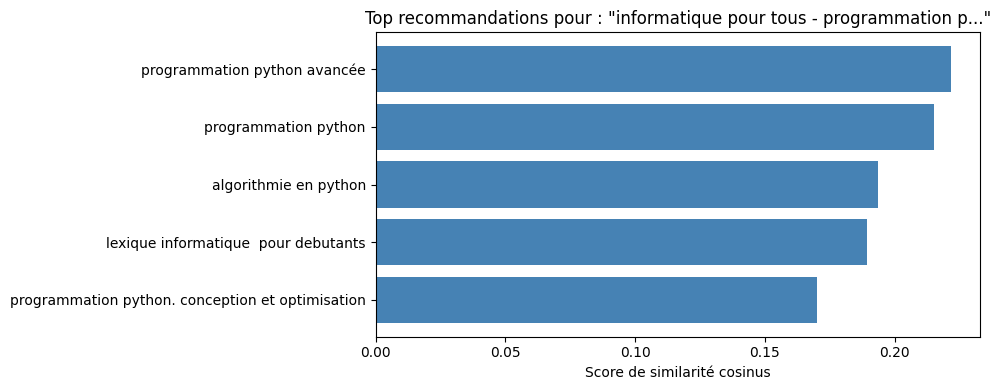

In [14]:
# --- Test 4 : visualisation des scores de similarité ---
if len(resultats) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(resultats['titre'].str[:50], resultats['score_similarite'], color='steelblue')
    ax.set_xlabel('Score de similarité cosinus')
    ax.set_title(f'Top recommandations pour : "{TITRE_TEST[:40]}..."')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 9. Évaluation qualitative

En l'absence de ratings utilisateurs, on évalue la pertinence par **cohérence de domaine** :
les ouvrages recommandés devraient appartenir au même domaine que la requête.

In [15]:
def evaluer_coherence_domaine(n_tests: int = 50, top_k: int = 5) -> float:
    """
    Mesure le taux de recommandations dans le même domaine que l'ouvrage requête.
    Indicateur de pertinence quand il n'y a pas de ratings.
    """
    echantillon = df.sample(min(n_tests, len(df)), random_state=42)
    scores = []

    for _, row in echantillon.iterrows():
        recos = recommander_ouvrage(row['titre'], n=top_k)
        if recos.empty:
            continue
        meme_domaine = (recos['domaine'] == row['domaine']).sum()
        scores.append(meme_domaine / top_k)

    coherence = np.mean(scores) if scores else 0.0
    print(f'✅ Cohérence de domaine (top-{top_k}, {len(scores)} tests) : {coherence:.2%}')
    return coherence

coherence = evaluer_coherence_domaine(n_tests=50, top_k=5)

✅ Cohérence de domaine (top-5, 50 tests) : 73.20%


## 10. Sauvegarde des artifacts

In [16]:
os.makedirs('artifacts', exist_ok=True)

# Sauvegarder tous les objets nécessaires à l'application Streamlit
pickle.dump(tfidf,       open('artifacts/uac_tfidf.pkl',      'wb'))
pickle.dump(tfidf_matrix,open('artifacts/uac_tfidf_matrix.pkl','wb'))
pickle.dump(cosine_sim,  open('artifacts/uac_cosine_sim.pkl', 'wb'))
pickle.dump(df,          open('artifacts/uac_df.pkl',         'wb'))

print('✅ Artifacts sauvegardés dans artifacts/')
print(f'   uac_tfidf.pkl       — vectoriseur TF-IDF')
print(f'   uac_tfidf_matrix.pkl — matrice TF-IDF')
print(f'   uac_cosine_sim.pkl  — matrice de similarité cosinus')
print(f'   uac_df.pkl          — DataFrame des ouvrages')

✅ Artifacts sauvegardés dans artifacts/
   uac_tfidf.pkl       — vectoriseur TF-IDF
   uac_tfidf_matrix.pkl — matrice TF-IDF
   uac_cosine_sim.pkl  — matrice de similarité cosinus
   uac_df.pkl          — DataFrame des ouvrages
